In [1]:
"""Smoke-test for the NEW Rossmann forecasting pipeline (hypertuning_new).

Runs the full feature-engineering -> target-transform -> inner-CV objective and
refit flow on a few real stores, then exercises hypertuning_new.optimize end-to-end
to validate the updated TimeSeriesCV(n_splits, train_size, test_size) API.
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.engine.cv import TimeSeriesCV
from src.engine import utils, hypertuning_new

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO,
                    filename=os.path.join(C.LOG_DIR, "test_pipeline_new.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)

c:\Users\Miltos.KALIKATZAR\AppData\Local\anaconda3\envs\rossmann\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

`config` merges the CV and study settings so `hypertuning_new.optimize` can read the inner-CV keys (`n_inner_splits`, `inner_train_size`, `inner_test_size`) used by the new `TimeSeriesCV` API.

In [2]:
cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": C.FORECAST_HORIZON,
    "inner_train_size": C.INNER_TRAIN_SIZE,
    "inner_test_size":  C.INNER_TEST_SIZE,
}

study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

# Merged config consumed by hypertuning_new.optimize
config = {**cv_config, **study_config}

In [3]:
""" Read the Rossmann store sales dataset and preprocess it for modeling. """
from src.preprocessing import preprocess_data, interpolate_closed_days, set_closed_to_zero


sales = pd.read_csv(r"C:/Users/Miltos.KALIKATZAR/Downloads/stuff/datasets/rossmann-store-sales/train.csv")
stores = pd.read_csv(r"C:/Users/Miltos.KALIKATZAR/Downloads/stuff/datasets/rossmann-store-sales/store.csv")

stores_to_use = [1, 2, 3, 4, 5, 6]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)
df = interpolate_closed_days(df)

# Feature engineering + target transform (new pipeline)

In [4]:
from src.engine.target_transformer import TargetTransformer

FORECAST_HORIZON = 10
windows = ['7D', '14D', '30D', '60D']
lags    = [pd.DateOffset(days=i) for i in range(FORECAST_HORIZON * 3)]
diffs   = [pd.DateOffset(days=i) for i in [3, 5, 7, 14, 30]]
horizon = pd.DateOffset(days=FORECAST_HORIZON)

y = (df
     .set_index(['Store', 'Date'])
     ['Sales'])

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, lags, diffs, windows, horizon)))

trf = TargetTransformer(forecast_horizon=pd.DateOffset(days=-FORECAST_HORIZON),
                        anchor_col='lag_days_0').fit(X)

y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target

# Single-trial smoke test of `_objective`

In [5]:
from optuna.trial import FixedTrial
from src.engine.hypertuning_new import _objective

# gap=FORECAST_HORIZON embargoes the last `horizon` dates before each test window
# so the forward-difference target cannot leak future sales into training.
inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE,
                        gap=FORECAST_HORIZON)

# Values must fall within the bounds defined in C.HYPERPARAMETERS
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                   study_name='stuff_new',
                                   study_config=config)

obj_fcn(mock_trial)

[0]	train-rmse:2.03972+0.06147	test-rmse:1.66579+1.21794
[100]	train-rmse:1.85125+0.05553	test-rmse:1.52513+1.11608
[200]	train-rmse:1.68091+0.05025	test-rmse:1.40087+1.02115
[300]	train-rmse:1.52705+0.04543	test-rmse:1.28885+0.93234
[400]	train-rmse:1.38798+0.04105	test-rmse:1.19304+0.85518
[500]	train-rmse:1.26246+0.03705	test-rmse:1.10688+0.78339
[600]	train-rmse:1.14887+0.03339	test-rmse:1.03133+0.71955
[700]	train-rmse:1.04650+0.03014	test-rmse:0.96514+0.66094
[800]	train-rmse:0.95397+0.02724	test-rmse:0.90822+0.60955
[900]	train-rmse:0.87052+0.02454	test-rmse:0.85784+0.56491
[1000]	train-rmse:0.79527+0.02213	test-rmse:0.81351+0.52451
[1100]	train-rmse:0.72737+0.02000	test-rmse:0.77339+0.48729
[1200]	train-rmse:0.66611+0.01807	test-rmse:0.73985+0.45754
[1300]	train-rmse:0.61093+0.01636	test-rmse:0.71072+0.42954
[1400]	train-rmse:0.56118+0.01467	test-rmse:0.68526+0.40518
[1500]	train-rmse:0.51640+0.01326	test-rmse:0.66304+0.38473
[1600]	train-rmse:0.47616+0.01198	test-rmse:0.64352+

np.float64(0.5324666322103772)

# Refit + predict + inverse transform

In [6]:
booster = hypertuning_new.refit(X, y, mock_trial, config)
test_dmatrix = xgb.DMatrix(X, enable_categorical=True)

preds = pd.Series(data=booster.predict(test_dmatrix), index=X.index, name='Sales')
preds = trf.inverse_transform(preds)

actuals = set_closed_to_zero(df).set_index(['Store', 'Date'])['Sales']
results = pd.merge(actuals, preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])
print(f"MAE: {mae:.2f}")

MAE: 598.82


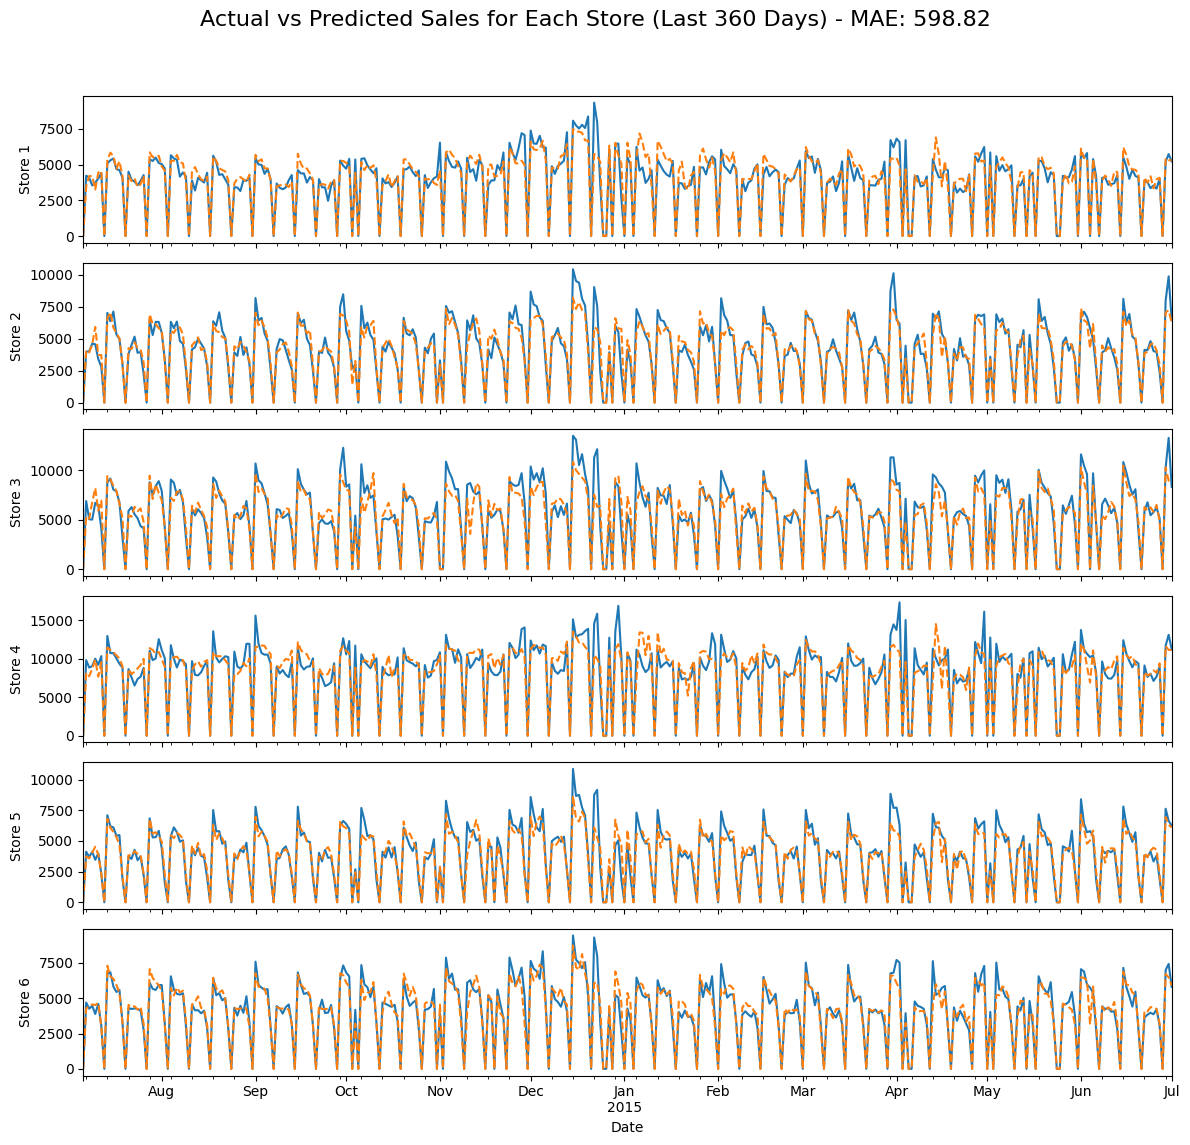

In [7]:
n_days_to_plot = 360
n_days_offset  = 1 * 30  # Offset to start plotting from 1 month ago

max_date = results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
preds_recent   = results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

plot_stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days) - MAE: {:.2f}".format(n_days_to_plot, mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle

# End-to-end `optimize` (validates the fixed `TimeSeriesCV` API)

Runs a couple of Optuna trials through the new `optimize`. Set `n_trials` small for a quick check.

In [8]:
# gap = FORECAST_HORIZON embargoes the inner CV inside optimize against target leakage.
smoke_config = {**config, "n_trials": 5, "n_startup_trials": 3, "gap": FORECAST_HORIZON}

hypertuning_new.optimize(study_name='smoke_new', X_train=X, y_train=y, config=smoke_config)

[0]	train-rmse:1.59798+0.04719	test-rmse:1.37165+0.99906
[25]	train-rmse:0.22055+0.00171	test-rmse:0.51696+0.27377
[0]	train-rmse:1.93518+0.05763	test-rmse:1.59875+1.16247
[100]	train-rmse:0.26697+0.00160	test-rmse:0.40080+0.15177
[103]	train-rmse:0.26551+0.00164	test-rmse:0.39671+0.15502
[0]	train-rmse:2.00414+0.06009	test-rmse:1.64301+1.19847
[100]	train-rmse:0.46414+0.01214	test-rmse:0.56944+0.27194
[200]	train-rmse:0.29256+0.00159	test-rmse:0.43028+0.16047
[300]	train-rmse:0.25857+0.00282	test-rmse:0.40977+0.14314
[400]	train-rmse:0.24536+0.00479	test-rmse:0.39961+0.13103
[488]	train-rmse:0.24035+0.00482	test-rmse:0.39385+0.12922
[0]	train-rmse:1.87407+0.05693	test-rmse:1.53726+1.10156
[88]	train-rmse:0.21950+0.00452	test-rmse:0.40881+0.12987
[0]	train-rmse:1.61419+0.04877	test-rmse:1.40510+0.99688


# Refit with best hyperparameters and plot

Load the finished study, grab the best trial's hyperparameters, refit a model on the full `(X, y)`, then plot actual vs predicted sales per store (same style as `test_pipeline`).

In [9]:
# Load the finished study and retrieve the best hyperparameters
study = optuna.load_study(study_name='smoke_new', storage=config["storage_url"])
best_trial = study.best_trial

print(f"Best trial: #{best_trial.number}")
print(f"Best value ({config['xgb_constants']['eval_metric']}): {best_trial.value:.6f}")
print(f"Best params: {best_trial.params}")

# Refit a model on the full dataset using the best hyperparameters
best_booster = hypertuning_new.refit(X, y, best_trial, config)

best_dmatrix = xgb.DMatrix(X, enable_categorical=True)
best_preds = pd.Series(data=best_booster.predict(best_dmatrix), index=X.index, name='Sales')
best_preds = trf.inverse_transform(best_preds)

actuals = set_closed_to_zero(df).set_index(['Store', 'Date'])['Sales']
best_results = pd.merge(actuals, best_preds, left_index=True, right_index=True, suffixes=('_actual', '_predicted'))

from sklearn.metrics import mean_absolute_error
best_mae = mean_absolute_error(best_results["Sales_actual"], best_results["Sales_predicted"])
print(f"Refit MAE: {best_mae:.2f}")

Best trial: #1
Best value (rmse): 0.391385
Best params: {'max_depth': 7, 'learning_rate': 0.05675206026988748, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 17, 'reg_alpha': 0.004335281794951566, 'reg_lambda': 0.004705059281907645, 'gamma': 0.36680901970686763}
Refit MAE: 535.65


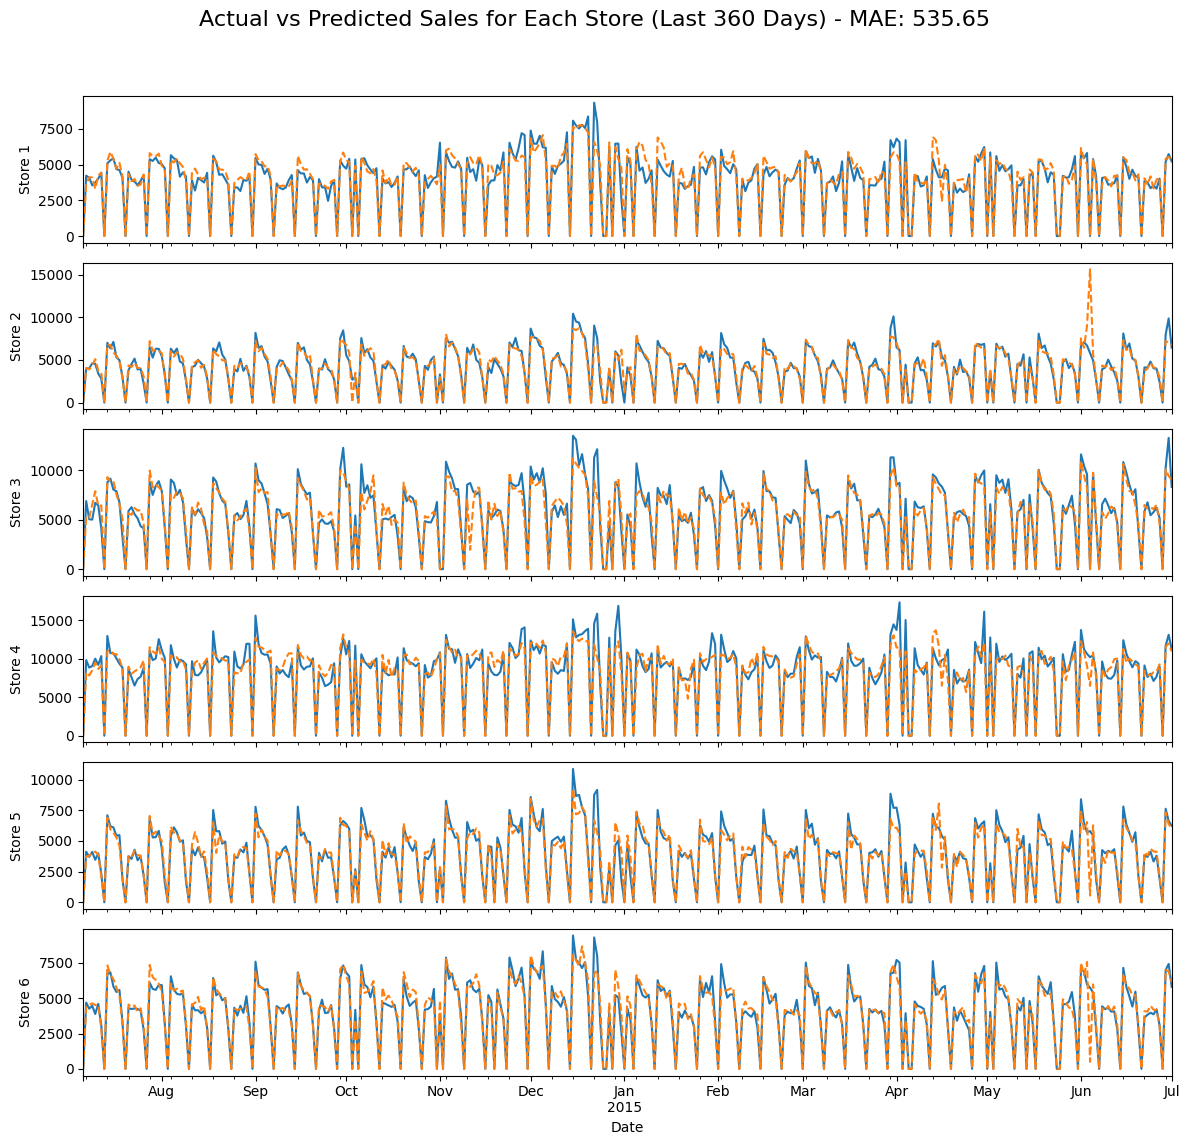

In [10]:
n_days_to_plot = 360
n_days_offset  = 1 * 30  # Offset to start plotting from 1 month ago

max_date = best_results.index.get_level_values("Date").max() - pd.Timedelta(days=n_days_offset)
min_date = max_date - pd.Timedelta(days=n_days_to_plot)

actuals_recent = best_results.loc[(slice(None), slice(min_date, max_date)), 'Sales_actual']
preds_recent   = best_results.loc[(slice(None), slice(min_date, max_date)), 'Sales_predicted']

plot_stores = actuals_recent.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = actuals_recent.loc[(store, slice(None))].copy()
    predicted_store_sales = preds_recent.loc[(store, slice(None))].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Actual vs Predicted Sales for Each Store (Last {} Days) - MAE: {:.2f}".format(n_days_to_plot, best_mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle

# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.

In [11]:
from sklearn.metrics import mean_absolute_error

# Embargo (gap) = FORECAST_HORIZON: drop the last `horizon` dates before every test
# window so the forward-difference target cannot leak future sales into training.
GAP = FORECAST_HORIZON

# Reuse the small/fast tuning budget; carry the embargo into the inner CV inside optimize.
nested_config = {**smoke_config, "gap": GAP}

# Outer CV: 3 folds, each test window = FORECAST_HORIZON steps per store.
N_OUTER_FOLDS    = 3
OUTER_TEST_SIZE  = FORECAST_HORIZON    # FORECAST_HORIZON steps per store

# Size the outer training window so the embargoed inner CV fits inside it:
# inner_train + n_inner * inner_test + gap, plus a small slack.
OUTER_TRAIN_SIZE = (nested_config["inner_train_size"]
                    + nested_config["n_inner_splits"] * nested_config["inner_test_size"]
                    + GAP + 10)

outer_cv = TimeSeriesCV(n_splits=N_OUTER_FOLDS,
                        train_size=OUTER_TRAIN_SIZE,
                        test_size=OUTER_TEST_SIZE,
                        gap=GAP)

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test           = X.iloc[test_idx]

    print(f"\n=== Outer fold {fold}/{N_OUTER_FOLDS} | train={len(X_train)} rows, test={len(X_test)} rows ===")

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    hypertuning_new.optimize(study_name=study_name,
                             X_train=X_train,
                             y_train=y_train,
                             config=nested_config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name, storage=nested_config["storage_url"])
    fold_booster = hypertuning_new.refit(X_train, y_train, study.best_trial, nested_config)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_dtest = xgb.DMatrix(X_test, enable_categorical=True)
    fold_preds = pd.Series(fold_booster.predict(fold_dtest), index=X_test.index, name='Sales')
    oof_preds.append(fold_preds)

# Combine all out-of-fold predictions and invert the target transform.
oof_preds = pd.concat(oof_preds)
oof_preds = trf.inverse_transform(oof_preds)

# Align the out-of-fold predictions with the actual sales.
oof_actuals = set_closed_to_zero(df).set_index(['Store', 'Date'])['Sales']
oof_results = pd.merge(oof_actuals, oof_preds, left_index=True, right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()

oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")


=== Outer fold 1/3 | train=4500 rows, test=60 rows ===
[0]	train-rmse:1.51402+0.08946	test-rmse:2.08623+0.22583
[86]	train-rmse:0.20363+0.01360	test-rmse:0.68313+0.21240
[0]	train-rmse:1.83253+0.11096	test-rmse:2.49496+0.24571
[100]	train-rmse:0.25194+0.01224	test-rmse:0.46742+0.09172
[127]	train-rmse:0.24020+0.01079	test-rmse:0.46786+0.08810
[0]	train-rmse:1.89774+0.11535	test-rmse:2.58366+0.25105
[100]	train-rmse:0.44168+0.02219	test-rmse:0.72491+0.18353
[200]	train-rmse:0.27696+0.01885	test-rmse:0.52163+0.19481
[300]	train-rmse:0.24532+0.01708	test-rmse:0.49479+0.19309
[400]	train-rmse:0.23405+0.01398	test-rmse:0.48510+0.18633
[484]	train-rmse:0.22970+0.01340	test-rmse:0.48174+0.18394
[0]	train-rmse:1.77676+0.10668	test-rmse:2.42714+0.24179
[100]	train-rmse:0.20976+0.01191	test-rmse:0.48057+0.11836
[118]	train-rmse:0.20322+0.01139	test-rmse:0.47977+0.11663
[0]	train-rmse:1.53091+0.08817	test-rmse:2.16015+0.17789

=== Outer fold 2/3 | train=4500 rows, test=60 rows ===
[0]	train-rmse

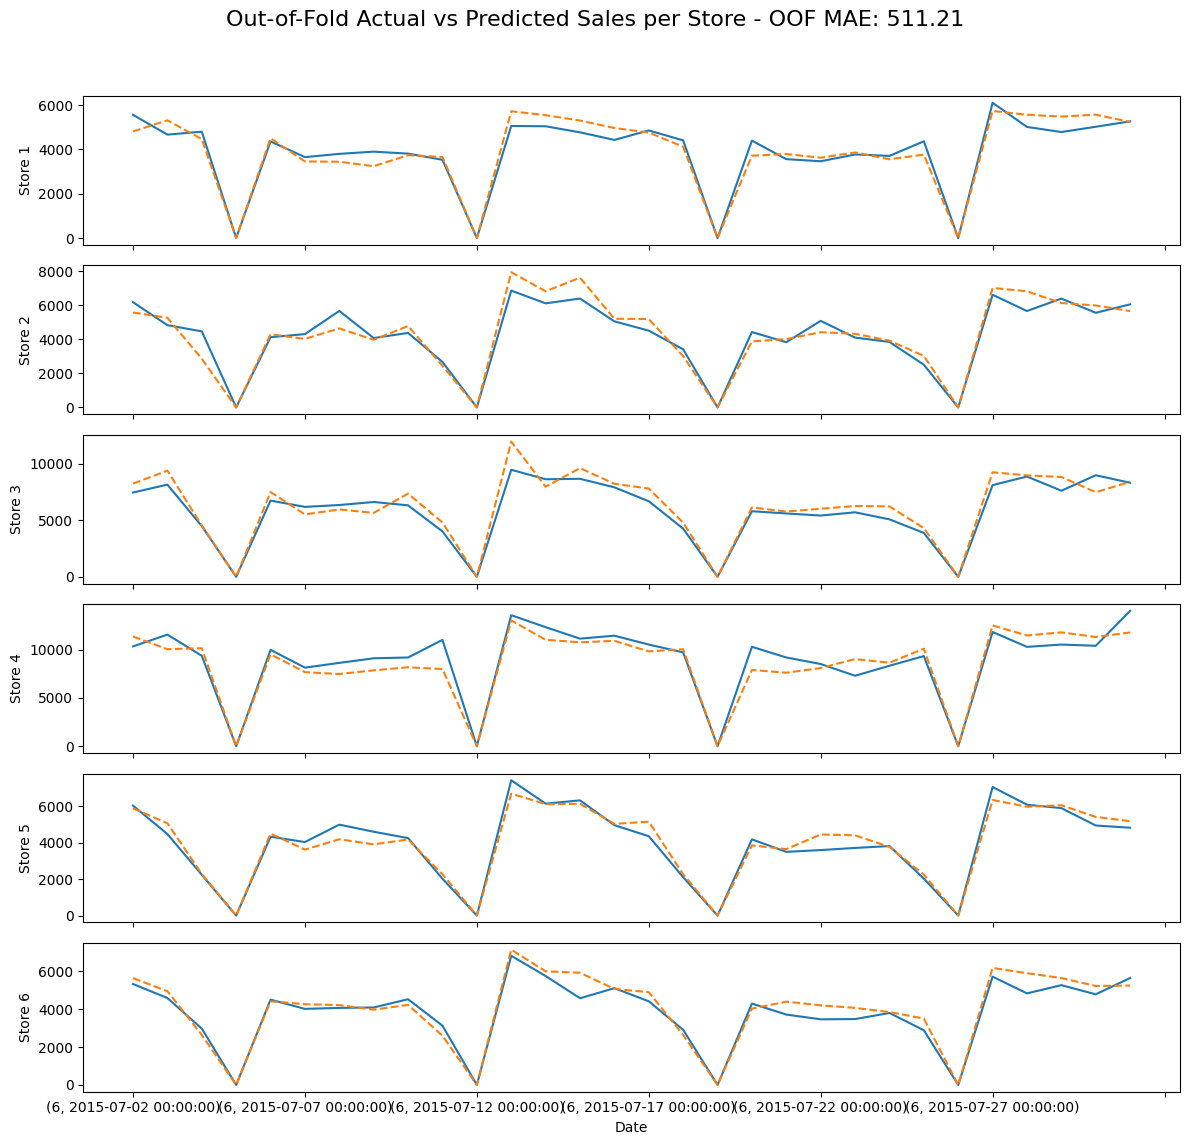

In [12]:
# Plot the out-of-fold predictions per store (same style as the earlier plots).
plot_stores = oof_results.index.get_level_values("Store").unique()

fig, ax = plt.subplots(figsize=(12, 2 * len(plot_stores)), nrows=len(plot_stores), sharex=True, sharey=False)

for i, store in enumerate(plot_stores):

    actual_store_sales    = oof_results.loc[(store, slice(None)), 'Sales_actual'].copy()
    predicted_store_sales = oof_results.loc[(store, slice(None)), 'Sales_predicted'].copy()

    actual_store_sales.fillna(method='ffill', inplace=True)     # Forward fill to maintain continuity in the plot
    predicted_store_sales.fillna(method='ffill', inplace=True)  # Forward fill to maintain continuity in the plot

    actual_store_sales.plot(label="Actual", ax=ax[i])
    predicted_store_sales.plot(label="Predicted", ax=ax[i], linestyle='--')

    ax[i].set_ylabel("Store {}".format(store))
    ax[i].set_xlabel("Date")

plt.suptitle("Out-of-Fold Actual vs Predicted Sales per Store - OOF MAE: {:.2f}".format(oof_mae), fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle